# Product Recommendation System
Simple end-to-end recommendations using popularity, collaborative, content-based, and hybrid approaches with ranking metrics.


## 1. Business Problem
Recommend relevant products to customers to improve product discovery and sales.


## 2. Business Objectives
- Recommend top and trending products
- Personalise recommendations using customer interactions
- Evaluate ranking quality


## 3. Recommendation Workflow
Popularity ? Collaborative Filtering ? Content-Based Filtering ? Hybrid Recommendations ? Evaluation


In [18]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

try:
    from surprise import SVD, Dataset, Reader
except ImportError:
    SVD = None

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None


## 4. Load Dataset


In [19]:
master_df = pd.read_parquet(Path("../data/processed/master_df.parquet"))
master_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


## 5. Dataset Overview


In [20]:
print("Dataset shape:", master_df.shape)
master_df[["customer_unique_id", "product_id", "order_purchase_timestamp"]].info()


Dataset shape: (2530433, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 3 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   customer_unique_id        object        
 1   product_id                object        
 2   order_purchase_timestamp  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 57.9+ MB


## 6. Data Quality Check


In [21]:
display(master_df[["customer_unique_id", "product_id", "review_score", "payment_value"]].isna().sum().to_frame("Missing"))


,Missing
customer_unique_id,0
product_id,0
review_score,167729
payment_value,0


## 7. Interaction Preparation


In [22]:
interaction_cols = ["customer_unique_id", "product_id", "order_purchase_timestamp", "review_score", "payment_value", "product_category_name", "seller_id"]
interactions = master_df[interaction_cols].dropna(subset=["customer_unique_id", "product_id"]).copy()
interactions["order_purchase_timestamp"] = pd.to_datetime(interactions["order_purchase_timestamp"])
interactions["review_score"] = interactions["review_score"].fillna(3)
interactions["payment_value"] = interactions["payment_value"].fillna(0)
interactions["product_category_name"] = interactions["product_category_name"].astype("object").fillna("unknown")
interactions["seller_id"] = interactions["seller_id"].astype("object").fillna("unknown")
interactions.head()


,customer_unique_id,product_id,order_purchase_timestamp,review_score,payment_value,product_category_name,seller_id
0,d45cdff2-5195-41e2-a0e5-6fe597e378dd,89804d82-33a1-4558-8fa2-9b0252a2a406,2025-12-27 07:07:20,3.0,2084.010010,furniture,36c2b043-ccf4-4d9c-a0bb-4b8d28737fd7
1,d45cdff2-5195-41e2-a0e5-6fe597e378dd,ac10b78c-342e-4b50-9ea9-bddde7db2e79,2025-12-27 07:07:20,3.0,2084.010010,electronics,09936504-415b-4f90-a5b8-ad15a5be67d0
2,d45cdff2-5195-41e2-a0e5-6fe597e378dd,f18e6310-0e75-4b7f-bc20-90ac1e7bd466,2025-12-27 07:07:20,3.0,2084.010010,fashion,7d336012-7101-4a66-b6bc-c269620d8df9
3,35cee471-325e-4ad2-8e4e-7b169dc6df81,5816f107-b725-4c41-b794-298bf9669a41,2019-06-07 19:30:44,5.0,1406.069946,furniture,91fe2cc8-51a5-4c79-9c12-cea5ae013f55
4,35cee471-325e-4ad2-8e4e-7b169dc6df81,f4b3ce27-568d-4c33-9248-6c314635f80a,2019-06-07 19:30:44,5.0,1406.069946,toys,54165da9-b969-4d50-9b61-ffd0d8b4d731


## 8. Duplicate Analysis


In [23]:
print("Duplicate interactions:", interactions.duplicated().sum())


Duplicate interactions: 10


## 9. Recommendation Definition


A recommendation is a ranked list of products a customer has not already interacted with. Interaction strength is based on rating and purchase value.


## 10. Product Interaction Features


In [24]:
interactions["interaction_score"] = interactions["review_score"] + np.log1p(interactions["payment_value"])
product_stats = interactions.groupby("product_id").agg(
    Popularity=("customer_unique_id", "count"),
    Average_Rating=("review_score", "mean"),
    Revenue=("payment_value", "sum"),
    Last_Purchase=("order_purchase_timestamp", "max")
).reset_index()
product_stats.head()


,product_id,Popularity,Average_Rating,Revenue,Last_Purchase
0,00078596-b7ae-4c45-b1e8-c9a480957b28,2827,3.712770,5.776690e+06,2025-12-31 21:03:15
1,001006dd-cbbd-41b9-9b6b-3607f0ab1981,1994,4.002508,2.048173e+06,2025-12-30 23:54:16
2,001304db-9813-4ffc-bf93-8b454eae1588,2026,4.038006,1.807408e+06,2025-12-31 21:18:47
3,001e7507-54d2-438b-9da0-59f31c3dc9cc,1363,4.052824,1.372973e+06,2025-12-31 17:10:11
4,003e6e7c-6357-40af-a3bb-6493d03b14c6,317,3.801262,4.466121e+05,2025-12-28 22:43:48


## 11. Stage 1: Popularity-Based Recommendation


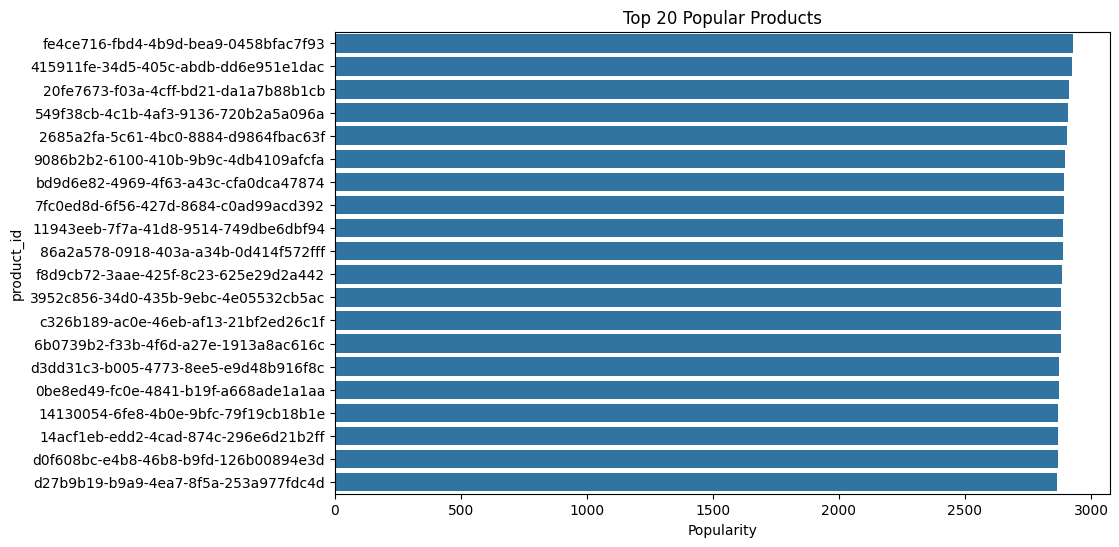

,product_id,Popularity,Average_Rating,Revenue,Last_Purchase
1983,fe4ce716-fbd4-4b9d-bea9-0458bfac7f93,2928,3.690574,5300429.50,2025-12-31 18:17:54
487,415911fe-34d5-405c-abdb-dd6e951e1dac,2924,3.710670,6538183.00,2025-12-31 23:47:07
253,20fe7673-f03a-4cff-bd21-da1a7b88b1cb,2914,3.711050,6123534.00,2025-12-31 18:17:48
629,549f38cb-4c1b-4af3-9136-720b2a5a096a,2910,3.682474,6436340.00,2025-12-31 15:15:04
289,2685a2fa-5c61-4bc0-8884-d9864fbac63f,2904,3.708678,5631904.50,2025-12-30 23:46:00
1056,9086b2b2-6100-410b-9b9c-4db4109afcfa,2898,3.710145,7802719.50,2025-12-31 22:46:25
1411,bd9d6e82-4969-4f63-a43c-cfa0dca47874,2893,3.823367,3916048.50,2025-12-31 23:19:06
928,7fc0ed8d-6f56-427d-8684-c0ad99acd392,2891,3.726046,5946404.50,2025-12-31 22:05:32
130,11943eeb-7f7a-41d8-9514-749dbe6dbf94,2889,3.703704,6482927.00,2025-12-31 20:58:04
975,86a2a578-0918-403a-a34b-0d414f572fff,2887,3.744371,5322628.50,2025-12-31 20:48:43


In [25]:
top_products = product_stats.sort_values(["Popularity", "Average_Rating"], ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x="Popularity", y="product_id")
plt.title("Top 20 Popular Products")
plt.show()
display(top_products)


## 12. Trending Products


In [26]:
recent_date = interactions["order_purchase_timestamp"].max() - pd.Timedelta(days=30)
trending_products = (interactions[interactions["order_purchase_timestamp"] >= recent_date]
    .groupby("product_id").agg(Recent_Orders=("customer_unique_id", "count"), Recent_Revenue=("payment_value", "sum"))
    .sort_values("Recent_Orders", ascending=False).head(20))
display(trending_products)


,Recent_Orders,Recent_Revenue
product_id,,
0e88ff02-746e-4719-bdd9-5073dc9864c8,243,712023.50000
4366f568-dbf2-4aea-a426-d0f19d4c0d94,237,458161.65625
cbceed2a-2fef-4be6-9b8b-e6e3b03a6863,233,662456.12500
0ea6ba79-a80c-483b-aa6e-630ba8c3857f,233,574807.87500
15c2ea76-3171-4b79-92ce-b598153a2167,232,570241.37500
549f38cb-4c1b-4af3-9136-720b2a5a096a,231,575760.12500
af5551b0-8223-45ef-9af5-8a55e10aaa8b,228,597357.18750
fe4ce716-fbd4-4b9d-bea9-0458bfac7f93,227,454262.87500
cc7a6d9c-5ae1-4cb9-bad6-37346f9cdb50,225,269668.43750


## 13. Train/Test Interaction Split


In [27]:
interactions = interactions.sort_values("order_purchase_timestamp")
test_interactions = interactions.groupby("customer_unique_id").tail(1)
train_interactions = interactions.drop(test_interactions.index)
print("Train interactions:", len(train_interactions))
print("Test interactions:", len(test_interactions))


Train interactions: 2251234
Test interactions: 279199


## 14. User-Item Matrix


In [28]:
# Keep collaborative filtering manageable: use customers with at least two interactions.
# All other customers receive popularity-based recommendations.
active_users = train_interactions.groupby("customer_unique_id").filter(lambda x: len(x) >= 2)
user_item = active_users.pivot_table(
    index="customer_unique_id",
    columns="product_id",
    values="interaction_score",
    aggfunc="mean",
    fill_value=0
)
user_ids = user_item.index.tolist()
product_ids = user_item.columns.tolist()
seen_products = train_interactions.groupby("customer_unique_id")["product_id"].apply(set).to_dict()
print("Collaborative-filtering matrix:", user_item.shape)


Collaborative-filtering matrix: (250089, 2000)


## 15. Stage 2: User-Based Collaborative Filtering


In [29]:
# Similarities are computed only for the requested user: shape (1, number_of_users).
def recommend_user_cf(user_id, k=10):
    if user_id not in user_item.index or len(user_item) <= 1:
        return top_products["product_id"].head(k).tolist()

    similarities = cosine_similarity(user_item.loc[[user_id]], user_item).ravel()
    similar_users = pd.Series(similarities, index=user_item.index).drop(user_id).nlargest(20)
    scores = pd.Series(similar_users.values @ user_item.loc[similar_users.index].values, index=product_ids)
    scores = scores.drop(labels=seen_products.get(user_id, set()), errors="ignore")
    return scores.sort_values(ascending=False).head(k).index.tolist()


## 16. Item-Based Collaborative Filtering


In [30]:
# Item similarities are computed only for products the requested user has interacted with.
def recommend_item_cf(user_id, k=10):
    if user_id not in user_item.index or len(product_ids) <= 1:
        return top_products["product_id"].head(k).tolist()

    liked_products = user_item.loc[user_id][user_item.loc[user_id] > 0].index
    scores = pd.Series(0.0, index=product_ids)
    for product_id in liked_products:
        similarities = cosine_similarity(user_item.T.loc[[product_id]], user_item.T).ravel()
        neighbours = pd.Series(similarities, index=product_ids).drop(product_id).nlargest(20)
        scores.loc[neighbours.index] += neighbours.values
    scores = scores.drop(labels=seen_products.get(user_id, set()), errors="ignore")
    return scores.sort_values(ascending=False).head(k).index.tolist()


## 17. Matrix Factorization (SVD)


In [31]:
# Matrix factorisation on the reduced collaborative-filtering matrix.
if min(user_item.shape) > 1:
    n_components = min(20, min(user_item.shape) - 1)
    svd_model = TruncatedSVD(n_components=n_components, random_state=42)
    user_factors = svd_model.fit_transform(user_item)
    item_factors = svd_model.components_

def recommend_svd(user_id, k=10):
    if user_id not in user_item.index or min(user_item.shape) <= 1:
        return top_products["product_id"].head(k).tolist()
    idx = user_item.index.get_loc(user_id)
    scores = pd.Series(user_factors[idx] @ item_factors, index=product_ids)
    scores = scores.drop(labels=seen_products.get(user_id, set()), errors="ignore")
    return scores.sort_values(ascending=False).head(k).index.tolist()


## 18. Surprise and implicit Libraries


In [32]:
if SVD is not None:
    print("Surprise is available for explicit-rating SVD experiments.")
else:
    print("Surprise is not installed; sklearn TruncatedSVD is used above.")
print("The user/item matrix above can also be passed to implicit ALS when implicit is installed.")


Surprise is not installed; sklearn TruncatedSVD is used above.
The user/item matrix above can also be passed to implicit ALS when implicit is installed.


## 19. Stage 3: Content-Based Recommendation


In [33]:
product_content = (interactions.groupby("product_id")
    .agg(Category=("product_category_name", "first"), Seller=("seller_id", "first"), Price=("payment_value", "mean"), Reviews=("review_score", "mean"))
    .reset_index())
product_content["content"] = (
    product_content["Category"].astype(str) + " " +
    product_content["Seller"].astype(str) + " price_" + product_content["Price"].round().astype(str) +
    " review_" + product_content["Reviews"].round().astype(str)
)
tfidf = TfidfVectorizer(stop_words="english")
content_matrix = tfidf.fit_transform(product_content["content"])
content_index = pd.Series(product_content.index, index=product_content["product_id"]).to_dict()


## 20. Content-Based Recommendation Function


In [34]:
def recommend_content(product_id, k=10):
    if product_id not in content_index:
        return top_products["product_id"].head(k).tolist()
    idx = content_index[product_id]
    similarities = cosine_similarity(content_matrix[idx], content_matrix).ravel()
    scores = pd.Series(similarities, index=product_content["product_id"])
    return scores.drop(product_id, errors="ignore").sort_values(ascending=False).head(k).index.tolist()


## 21. Sentence Transformers and BERT Embeddings


In [35]:
if SentenceTransformer is not None:
    print("Sentence Transformers is available for BERT-based product embeddings.")
    # embedder = SentenceTransformer("all-MiniLM-L6-v2")
    # product_embeddings = embedder.encode(product_content["content"].tolist())
else:
    print("Sentence Transformers is not installed; TF-IDF content vectors are used.")


Sentence Transformers is available for BERT-based product embeddings.


## 22. Stage 4: Hybrid Recommendation


In [36]:
def hybrid_recommend(user_id, k=10):
    candidates = recommend_user_cf(user_id, 30) + recommend_item_cf(user_id, 30) + recommend_svd(user_id, 30)
    if user_id in seen_products and seen_products[user_id]:
        last_product = train_interactions[train_interactions["customer_unique_id"] == user_id].iloc[-1]["product_id"]
        candidates += recommend_content(last_product, 30)
    candidates += top_products["product_id"].head(30).tolist()
    candidates = [p for p in candidates if p not in seen_products.get(user_id, set())]
    return pd.Series(candidates).value_counts().head(k).index.tolist()


## 23. Sample Recommendations


In [37]:
sample_user = user_ids[0]
print("Sample user:", sample_user)
print("User CF:", recommend_user_cf(sample_user))
print("Item CF:", recommend_item_cf(sample_user))
print("SVD:", recommend_svd(sample_user))
print("Hybrid:", hybrid_recommend(sample_user))


Sample user: 00004453-ecfa-4c25-94f1-0004cc58286f
User CF: ['06de5246-e6e7-49f9-ac9d-9e9e3c42d404', 'ce50baab-5d3d-417f-a025-bcba46ac36e3', 'f68621b0-8316-4cc4-9ba6-af209132acd6', 'af441f79-0c95-4bae-9a12-acb08df07577', '18d57f06-677d-4ede-b08e-5da6e6e54ea3', '1f764d50-64cd-4edb-a4de-55403c67e940', '343e9bdf-424c-443f-a648-e595ac8fb6da', '8ce5fa0f-09b5-4fa6-8192-de7cb6d34d74', '5d755d64-6cf7-4d17-a953-e6ea00abd771', '40a1a269-157d-42d9-a526-4dea77bdb2c0']
Item CF: ['a7d693c8-776c-4b07-a5b8-e360c90ead30', 'ac348ed4-95bb-4ec0-ad10-d5ec32154fae', '8ce5fa0f-09b5-4fa6-8192-de7cb6d34d74', 'ecc40aa4-0dc9-4c3d-b5ff-7a7c1e9cba49', '001304db-9813-4ffc-bf93-8b454eae1588', 'f44861d4-82ed-44fd-976b-c601c95e919c', '17299769-1767-4924-882b-978d6cac5627', '28fbedaf-30dc-4baf-af92-6605dfcdf7e3', '7fc0ed8d-6f56-427d-8684-c0ad99acd392', 'fb355797-e3be-45b4-911c-5efa3fc76f74']
SVD: ['833b5830-3753-4368-8f85-3c520f5dc5b8', 'ef9f36f8-ef7b-4a26-bc7b-ebf1d7c0797d', 'e7fbc23d-039d-41ef-9312-03cd46caf568', 'e4b

## 24. Ranking Metrics


In [38]:
def precision_at_k(recommended, actual, k=10):
    return len(set(recommended[:k]) & set(actual)) / k

def recall_at_k(recommended, actual, k=10):
    return len(set(recommended[:k]) & set(actual)) / max(len(actual), 1)

def average_precision(recommended, actual, k=10):
    hits, score = 0, 0
    for i, product in enumerate(recommended[:k], start=1):
        if product in actual:
            hits += 1
            score += hits / i
    return score / max(len(actual), 1)

def ndcg_at_k(recommended, actual, k=10):
    dcg = sum(1 / np.log2(i + 2) for i, p in enumerate(recommended[:k]) if p in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / idcg if idcg else 0


## 25. Hybrid Model Evaluation


In [48]:
import time

# -----------------------------
# Sample users for evaluation
# -----------------------------
N_USERS = 100   # Change to 500 or 1000 after testing

sample_users = (
    test_interactions["customer_unique_id"]
    .drop_duplicates()
    .sample(n=min(N_USERS, test_interactions["customer_unique_id"].nunique()),
            random_state=42)
)

# -----------------------------
# Create lookup dictionary
# (Much faster than filtering every iteration)
# -----------------------------
actual_lookup = (
    test_interactions
    .groupby("customer_unique_id")["product_id"]
    .apply(list)
    .to_dict()
)

# -----------------------------
# Evaluate
# -----------------------------
evaluation_rows = []

start_time = time.time()

for i, user_id in enumerate(sample_users, start=1):

    if i % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i}/{len(sample_users)} users | Elapsed: {elapsed:.1f} sec")

    actual = actual_lookup[user_id]

    recommendations = hybrid_recommend(user_id, k=10)

    evaluation_rows.append({
        "Precision@10": precision_at_k(recommendations, actual),
        "Recall@10": recall_at_k(recommendations, actual),
        "MAP": average_precision(recommendations, actual),
        "NDCG": ndcg_at_k(recommendations, actual)
    })

# -----------------------------
# Average metrics
# -----------------------------
metrics = pd.DataFrame(evaluation_rows).mean().to_frame("Score")


display(metrics)

Processed 10/100 users | Elapsed: 325.4 sec
Processed 20/100 users | Elapsed: 616.6 sec
Processed 30/100 users | Elapsed: 897.3 sec
Processed 40/100 users | Elapsed: 1089.0 sec
Processed 50/100 users | Elapsed: 1378.9 sec
Processed 60/100 users | Elapsed: 1573.1 sec
Processed 70/100 users | Elapsed: 1838.4 sec
Processed 80/100 users | Elapsed: 2030.9 sec
Processed 90/100 users | Elapsed: 2241.8 sec
Processed 100/100 users | Elapsed: 2401.7 sec


,Score
Precision@10,0.001000
Recall@10,0.010000
MAP,0.001111
NDCG,0.003010


## 26. Recommendation Model Comparison


In [49]:
print("Popularity supports cold-start users.")
print("User CF, Item CF, and SVD personalise recommendations from interactions.")
print("Content-based recommendations use category, seller, price, and reviews.")
print("Hybrid recommendations combine all available signals.")


Popularity supports cold-start users.
User CF, Item CF, and SVD personalise recommendations from interactions.
Content-based recommendations use category, seller, price, and reviews.
Hybrid recommendations combine all available signals.


## 27. Product Recommendation Output


In [50]:
recommendation_output = pd.DataFrame({
    "customer_unique_id": user_ids[:20],
    "recommended_products": [hybrid_recommend(user_id, 10) for user_id in user_ids[:20]]
})
display(recommendation_output)


,customer_unique_id,recommended_products
0,00004453-ecfa-4c25-94f1-0004cc58286f,"[86a2a578-0918-403a-a34b-0d414f572fff, 06de524..."
1,000062e5-a9a0-4056-a54d-5cf0b2473fda,"[415911fe-34d5-405c-abdb-dd6e951e1dac, 9086b2b..."
2,000076de-9d04-4ae8-af41-2f8caf66c899,"[0be8ed49-fc0e-4841-b19f-a668ade1a1aa, 14acf1e..."
3,00008df1-f9ce-487d-b5a6-68e6992e025a,"[83fbdf52-21a3-4b64-af45-76ff4437130b, 42cf9a6..."
4,00009e20-cfbd-4b4b-b304-38868364135e,"[1ae634ff-c729-4828-899d-6e303658704c, 6b0739b..."
5,0000aa69-779b-49ee-84ad-d01fa3432bfc,"[3952c856-34d0-435b-9ebc-4e05532cb5ac, 3b4330b..."
6,0000c6d2-bb39-4777-80f9-0faea7bdd29d,"[f8d9cb72-3aae-425f-8c23-625e29d2a442, 20fe767..."
7,0000f4d3-5d38-42c4-945b-a3c1efd6d9f5,"[fe4ce716-fbd4-4b9d-bea9-0458bfac7f93, 236a951..."
8,0001451a-3cb2-4361-aa93-d6bb2270f320,"[4bff9d5d-1406-4879-b009-521289c0b475, 1f2e01b..."
9,0001c917-2aef-4ffc-896e-424083b20cac,"[86a2a578-0918-403a-a34b-0d414f572fff, 6c2d88c..."


## 28. Business Insights


In [51]:
print("Top products are useful for new customers and low-data users.")
print("Personalised hybrid recommendations can improve discovery of relevant products.")
print("Use ranking metrics to monitor recommendation quality over time.")


Top products are useful for new customers and low-data users.
Personalised hybrid recommendations can improve discovery of relevant products.
Use ranking metrics to monitor recommendation quality over time.


## 29. Deployment Recommendation


In [52]:
print("Use popularity recommendations for cold-start customers.")
print("Use the hybrid recommender for customers with purchase history.")
print("Refresh interaction and product-content data regularly.")


Use popularity recommendations for cold-start customers.
Use the hybrid recommender for customers with purchase history.
Refresh interaction and product-content data regularly.


## 30. Model Export


In [57]:
# ==========================================================
# Create models directory
# ==========================================================
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Save Recommendation System 
# ==========================================================
model_path = MODEL_DIR / "product_recommender_system.joblib"

recommender_system = {
    "user_item_matrix": user_item,
    "svd_model": svd_model,
    "product_content": product_content
}

joblib.dump(recommender_system, model_path)

print("=" * 60)
print("Recommendation System Saved Successfully!")
print(f"Location : {model_path}")
print("=" * 60)

Recommendation System Saved Successfully!
Location : ..\models\product_recommender_system.joblib


## 31. Executive Summary


In [54]:
print("Product recommendation workflow completed.")
print("Stages included: popularity, collaborative filtering, content-based filtering, and hybrid recommendations.")
print(metrics)


Product recommendation workflow completed.
Stages included: popularity, collaborative filtering, content-based filtering, and hybrid recommendations.
                 Score
Precision@10  0.001000
Recall@10     0.010000
MAP           0.001111
NDCG          0.003010
